<a href="https://colab.research.google.com/github/penajuanmanuel6-hub/automated-etl-pipeline/blob/main/optimizacion_logistica_albergues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. CONFIGURACIÓN DE LA BASE DE DATOS LOGÍSTICA (SQL) ---
--- 2. EJECUCIÓN DE CONSULTA SQL Y CÁLCULO PREDICTIVO ---
                Albergue  Stock_Actual  Dias_Para_Agotamiento  Prioridad_Score
Albergue Sur - Periferia          4200                    2.0             34.0
         Albergue Centro         10500                    3.0              4.0
     Albergue Zona Norte          6000                    5.0              9.0
      Albergue Occidente          4500                    5.0              5.0


--- 3. GENERACIÓN DE MATRIZ DE RIESGO Y RUTAS LOGÍSTICAS ---


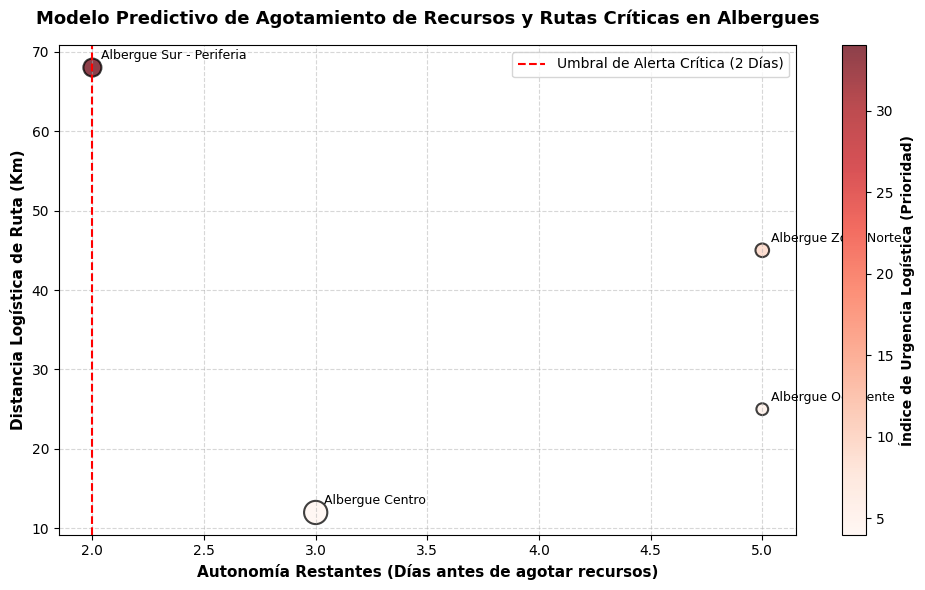

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CONFIGURACIÓN DE LA BASE DE DATOS Y CARGA DE DATOS (ETL & SQL)
# ==============================================================================
print("--- 1. CONFIGURACIÓN DE LA BASE DE DATOS LOGÍSTICA (SQL) ---")

conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

# Creación de tablas relacionales para Albergues e Inventarios de Ayuda
cursor.execute("""
CREATE TABLE albergues (
    albergue_id INTEGER PRIMARY KEY,
    nombre_albergue TEXT,
    zona TEXT,
    personas_alojadas INTEGER,
    distancia_km REAL
);
""")

cursor.execute("""
CREATE TABLE inventarios (
    item_id INTEGER PRIMARY KEY,
    albergue_id INTEGER,
    recurso TEXT,
    stock_actual INTEGER,
    consumo_diario_estimado INTEGER,
    FOREIGN KEY (albergue_id) REFERENCES albergues(albergue_id)
);
""")

# Inserción de datos simulados post-terremoto
albergues_data = [
    (1, 'Albergue Zona Norte', 'Norte', 1200, 45.0),
    (2, 'Albergue Centro', 'Centro', 3500, 12.0),
    (3, 'Albergue Sur - Periferia', 'Sur', 2100, 68.0),
    (4, 'Albergue Occidente', 'Occidente', 900, 25.0)
]

inventarios_data = [
    (101, 1, 'Kits de Agua (Litros)', 6000, 1200),
    (102, 2, 'Kits de Agua (Litros)', 10500, 3500),
    (103, 3, 'Kits de Agua (Litros)', 4200, 2100),
    (104, 4, 'Kits de Agua (Litros)', 4500, 900)
]

cursor.executemany("INSERT INTO albergues VALUES (?, ?, ?, ?, ?)", albergues_data)
cursor.executemany("INSERT INTO inventarios VALUES (?, ?, ?, ?, ?)", inventarios_data)
conn.commit()

# ==============================================================================
# 2. CONSULTA SQL Y MODELO PREDICTIVO DE AGOTAMIENTO
# ==============================================================================
print("--- 2. EJECUCIÓN DE CONSULTA SQL Y CÁLCULO PREDICTIVO ---")

query = """
SELECT
    a.nombre_albergue AS Albergue,
    a.zona AS Zona,
    a.personas_alojadas AS Poblacion,
    a.distancia_km AS Distancia_Ruta_KM,
    i.recurso AS Recurso,
    i.stock_actual AS Stock_Actual,
    i.consumo_diario_estimado AS Consumo_Diario
FROM albergues a
JOIN inventarios i ON a.albergue_id = i.albergue_id;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Modelo predictivo matemático: Días de autonomía hasta el colapso/agotamiento del recurso
df['Dias_Para_Agotamiento'] = df['Stock_Actual'] / df['Consumo_Diario']

# Índice de Prioridad Logística (Combina urgencia por días de inventario y distancia de ruta)
# Menor días de stock y mayor distancia aumentan drásticamente la prioridad de despacho
df['Prioridad_Score'] = (df['Distancia_Ruta_KM'] / df['Dias_Para_Agotamiento'])

df = df.sort_values(by='Dias_Para_Agotamiento', ascending=True)

print(df[['Albergue', 'Stock_Actual', 'Dias_Para_Agotamiento', 'Prioridad_Score']].to_string(index=False))
print("\n")

# ==============================================================================
# 3. VISUALIZACIÓN EJECUTIVA CON MATPLOTLIB (OPTIMIZACIÓN LOGÍSTICA)
# ==============================================================================
print("--- 3. GENERACIÓN DE MATRIZ DE RIESGO Y RUTAS LOGÍSTICAS ---")

plt.figure(figsize=(10, 6))

# Gráfico de dispersión: Días de Autonomía vs Distancia de Ruta (El tamaño indica la población afectada)
scatter = plt.scatter(
    df['Dias_Para_Agotamiento'],
    df['Distancia_Ruta_KM'],
    s=df['Poblacion'] * 0.08,  # Tamaño proporcional al número de personas en el albergue
    c=df['Prioridad_Score'],   # Color según la urgencia crítica
    cmap='Reds',
    alpha=0.75,
    edgecolors='black',
    linewidth=1.5
)

cbar = plt.colorbar(scatter)
cbar.set_label('Índice de Urgencia Logística (Prioridad)', fontweight='semibold')

plt.title("Modelo Predictivo de Agotamiento de Recursos y Rutas Críticas en Albergues", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Autonomía Restantes (Días antes de agotar recursos)", fontsize=11, fontweight='semibold')
plt.ylabel("Distancia Logística de Ruta (Km)", fontsize=11, fontweight='semibold')
plt.grid(True, linestyle='--', alpha=0.5)

# Línea de umbral crítico de alerta temprana (ej. menos de 2 días de inventario)
plt.axvline(x=2.0, color='red', linestyle='--', linewidth=1.5, label='Umbral de Alerta Crítica (2 Días)')
plt.legend(loc='upper right')

# Anotaciones automáticas para identificar los albergues en el mapa de riesgos
for i, txt in enumerate(df['Albergue']):
    plt.annotate(
        txt,
        (df['Dias_Para_Agotamiento'].iloc[i], df['Distancia_Ruta_KM'].iloc[i]),
        fontsize=9,
        fontweight='medium',
        xytext=(6, 6),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()